In [27]:
# собственно подключаем зависимости
import torch

import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchinfo import summary
from torch import nn

Загружаем датасет, по отдельности скачав выборки train и test

In [28]:
train_dataset = datasets.MNIST(root='mnist', train=True, download=True, transform=ToTensor())
test_dataset = datasets.MNIST(root="mnist", train=False, download=True, transform=ToTensor())

Выберем функцию лосса

In [29]:
# your code here
loss_function = nn.CrossEntropyLoss()

Позже мы не будем менять её, кросс энтропия идеально нам подходит, так как объединяет LogSoftmax и NLLLoss, и очень хороша для классификации изображений, чем мы и будем заниматься

Напишем функцию run (возьмём её из практики 5), но добавим подсчёт аккуратности, чтобы видеть наглядно обучение модели

In [30]:
def run(model, dataloader, loss_function, optimizer=None):
    # set the model to evaluation or training mode
    if optimizer == None:
        model.eval()
    else:
        model.train()

    total_loss = 0
    correct_preds = 0
    total_samples = 0

    for X, y in dataloader:
        # compute prediction
        pred = model(X)
        
        # compute loss
        loss = loss_function(pred, y)

        # save loss
        total_loss += loss.item()

        if optimizer != None:
            # compute gradients
            loss.backward()

            # do optimizer step
            optimizer.step()

            # clear gradients
            optimizer.zero_grad()
        
        correct_preds += (pred.argmax(1) == y).type(torch.float).sum().item()
        total_samples += len(y)

    return total_loss / len(dataloader), correct_preds / total_samples

И функцию для отрисовки графика потерь и аккуратности

In [38]:
from IPython.display import clear_output

def show_losses(train_loss_hist, train_acc_hist):
    clear_output()

    plt.figure(figsize=(12,4))

    plt.subplot(1, 2, 1)
    plt.title('Train Loss')
    plt.plot(np.arange(len(train_loss_hist)), train_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title('Train accuracy')
    plt.plot(np.arange(len(train_acc_hist)), train_acc_hist)
    plt.yscale('log')
    plt.grid()
    
    plt.show()

Используем 30 эпох, так как loss падает довольно быстро и модель начинает просто заучивать картинки

In [32]:
NUM_EPOCHS = 30

Также разбиваем выборку на батчи для скорости вычисления градиента, размер батча упирает в мощность видеокарты, 
я выберу 100, так как мне важна скорость вычислений и стабильность, что и даёт это значение

In [33]:
BATCH_SIZE = 100
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

Дальше нужно выберать оптимизатор, у нас есть SGD и Adam (SGD с адаптивным моментумом)
предлагаю протестировать, что лучше позже

напишем функцию тренировки

In [34]:
from torch import optim

def model_train(model, num_epoch=NUM_EPOCHS, lr=0.01):
    train_loss_hist = []
    train_acc_hist = []
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for i in range(num_epoch):

        train_loss, train_acc = run(model, train_loader, loss_function, optimizer)
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        if i % 10 == 9:
            show_losses(train_loss_hist, train_acc_hist)

def model_train_sgd(model, num_epoch=NUM_EPOCHS, lr=0.01):
    train_loss_hist = []
    train_acc_hist = []
    optimizer_sgd = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    for i in range(num_epoch):

        train_loss, train_acc = run(model, train_loader, loss_function, optimizer_sgd)
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        if i % 10 == 9:
            show_losses(train_loss_hist, train_acc_hist)

Приступим к написанию нашей первой модели, на которой мы будем тестировать 

In [ ]:
model_784_256_128_10_sqd = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

model_784_256_128_10_adam = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

summary(model_784_256_128_10_sqd) # они одинаковые так что саммари только для 1-ой

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─ReLU: 1-3                              --
├─Linear: 1-4                            32,896
├─ReLU: 1-5                              --
├─Linear: 1-6                            1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0

Она не самая простая, но, думаю, для подбора значений перед изменением архитектуры её хватит

для начала проверим оптимизатор

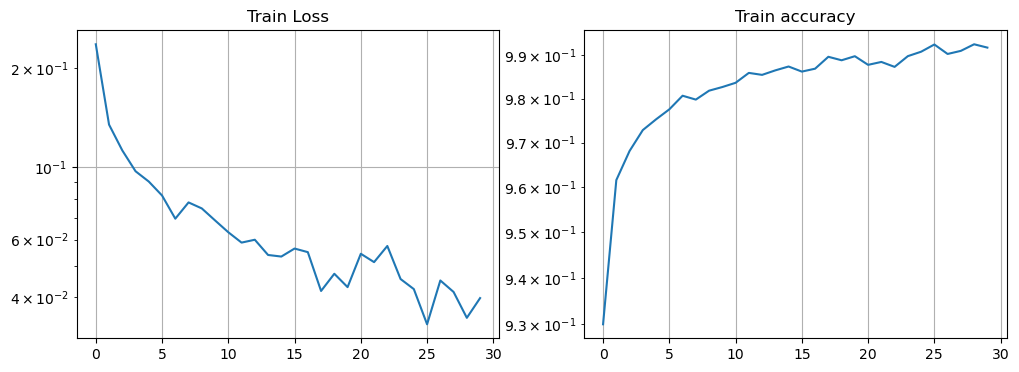

In [52]:
model_train(model_784_256_128_10_adam)

и проверим sgd

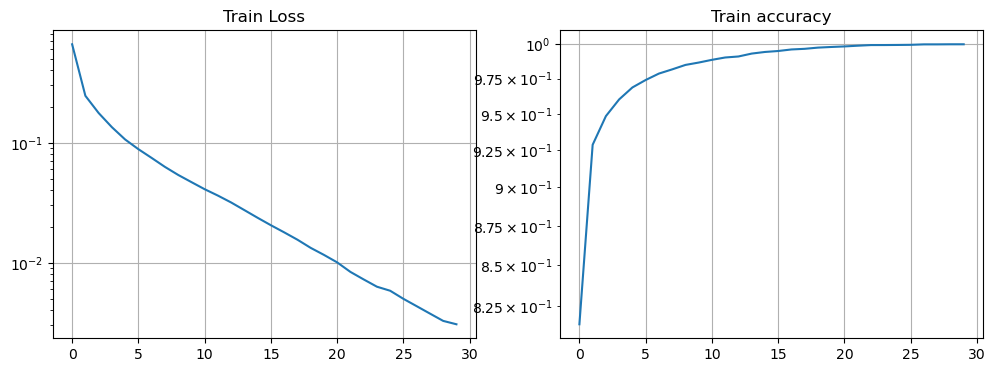

In [53]:
model_train_sgd(model_784_256_128_10_sqd)

То что можно заметить сразу, эпох много и график сошёлся слишком быстро в обоих случаях

Проверим тестовую выборку и показатели моделей

Напишем функцию для проверки модели

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
def evaluate_metrics(model):

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)

    return acc, precision, recall, f1

функцию для красивого вывода предсказаний 

In [45]:
# Function to show predictions
def show_predictions(images, labels, preds):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(images[i].cpu().reshape(28, 28), cmap='gray')
        color = 'green' if preds[i] == labels[i] else 'red'
        axes[i].set_title(f"Pred: {preds[i]}, True: {labels[i]}", color=color)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

функцию на основе прошлой для первых 10 изображений

In [46]:
def show_first_ten_tests(model):
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Show predictions
    show_predictions(images[:10], labels[:10], preds[:10])

посмотрим на показатели моделек

In [55]:
# Evaluate the model
model_784_256_128_10_adam.eval()
results = evaluate_metrics(model_784_256_128_10_adam)
print("ADAM")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_128_10_sqd.eval()
results = evaluate_metrics(model_784_256_128_10_sqd)
print("SGD")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

ADAM
acuracity: 0.9742
precision: 0.9740972645515079
recall: 0.9739951539450933
f1: 0.9739599130851533

SGD
acuracity: 0.9816
precision: 0.9816016747310858
recall: 0.9814797161701773
f1: 0.9815344199874003


...

мы видим, что SGD на 30 эпохах показал лучший результат, хоть Adam и сошёлся быстрее, но SGD смог полностью заучить тренировочную выборку (что плохо, но это ему помогло быть более точным на тестовой) и был более стабильным и быстрым, поэтому я остановлюсь на SGD

Примеры работы

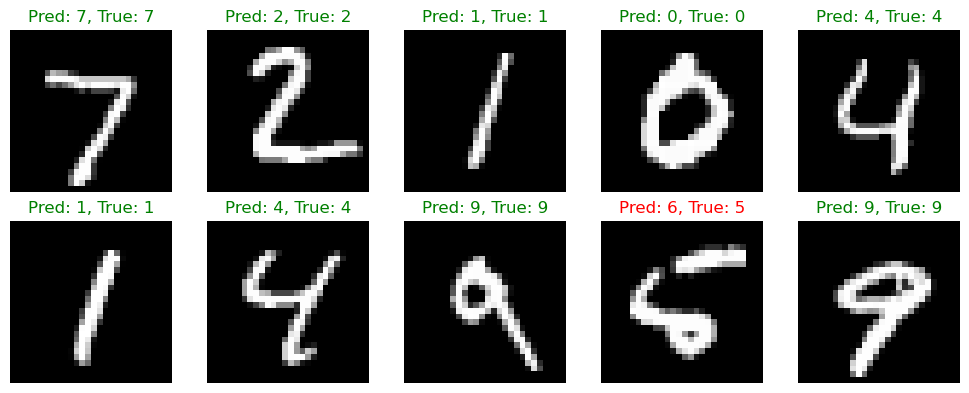

In [ ]:
show_first_ten_tests(model_784_256_128_10_sqd)

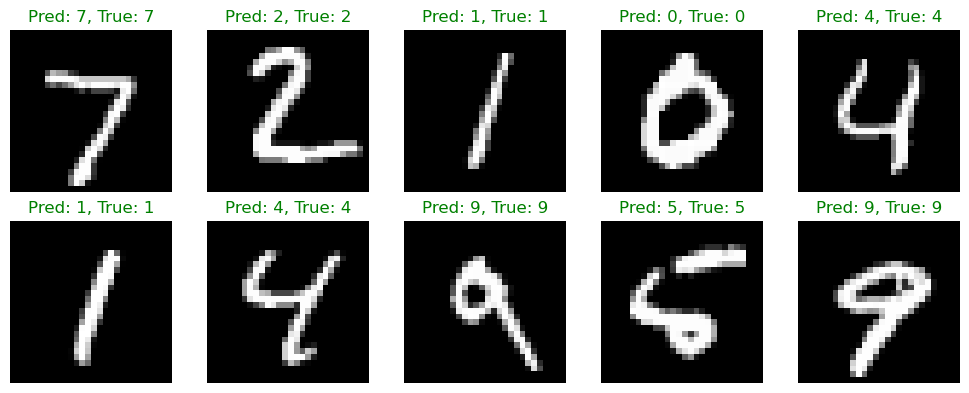

In [56]:
show_first_ten_tests(model_784_256_128_10_adam)

Однако, что же там с эпохами, я предлагаю взять 10, 20, 30 (дальше уже плохо оно уже заучило тренировочную выборку) и посмотреть на показатели

In [58]:
# создадим ещё 2 одинаковых модельки

model_784_256_128_10_sqd_20_epoch = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

model_784_256_128_10_sqd_10_epoch = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

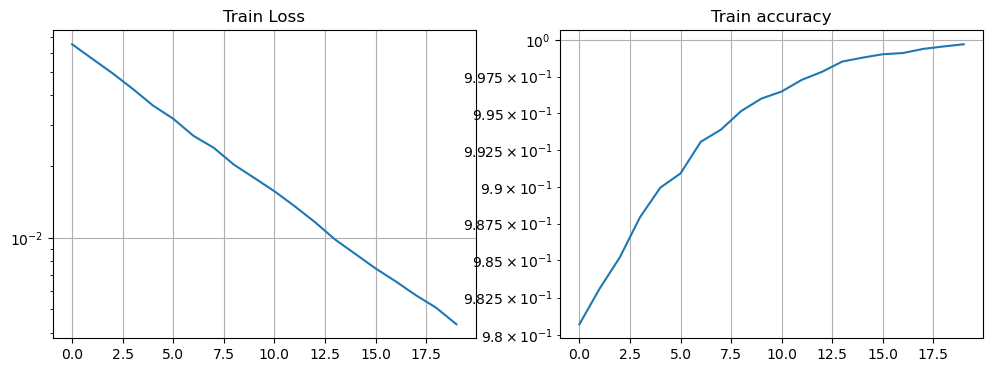

In [60]:
model_train_sgd(model_784_256_128_10_sqd_20_epoch, num_epoch=20)

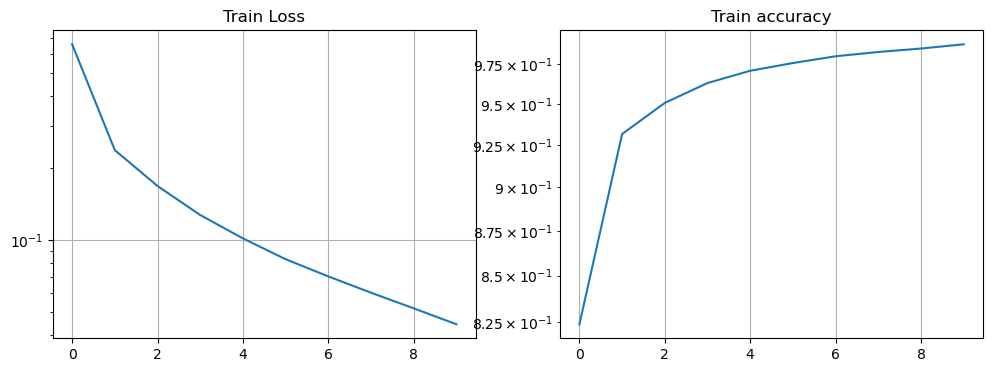

In [61]:
model_train_sgd(model_784_256_128_10_sqd_10_epoch, num_epoch=10)

In [64]:
# Evaluate the model
model_784_256_128_10_sqd.eval()
results = evaluate_metrics(model_784_256_128_10_sqd)
print("30 epoch")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_128_10_sqd_20_epoch.eval()
results = evaluate_metrics(model_784_256_128_10_sqd_20_epoch)
print("20 epoch")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_128_10_sqd_10_epoch.eval()
results = evaluate_metrics(model_784_256_128_10_sqd_10_epoch)
print("10 epoch")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

30 epoch
acuracity: 0.9816
precision: 0.9816016747310858
recall: 0.9814797161701773
f1: 0.9815344199874003

20 epoch
acuracity: 0.9813
precision: 0.9812815324076549
recall: 0.9811170130099022
f1: 0.9811874475696284

10 epoch
acuracity: 0.9773
precision: 0.9772022774000131
recall: 0.9771365278248322
f1: 0.9771346458098149


Интересно, всё же 30 эпох, стали самими стабильными, тогда наши опасения были неверны, хотя разница между 20 небольшая, позже у нас может случиться что график может не сойтись из-за 20 эпох

И последнее что мы проверим перед самими архитектурами это шаг (lr) 

In [ ]:
model_784_256_128_10_sqd_lr_0001 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

model_784_256_128_10_sqd_lr_01 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

# саммари нет так как структура одинаковая с model_sgd

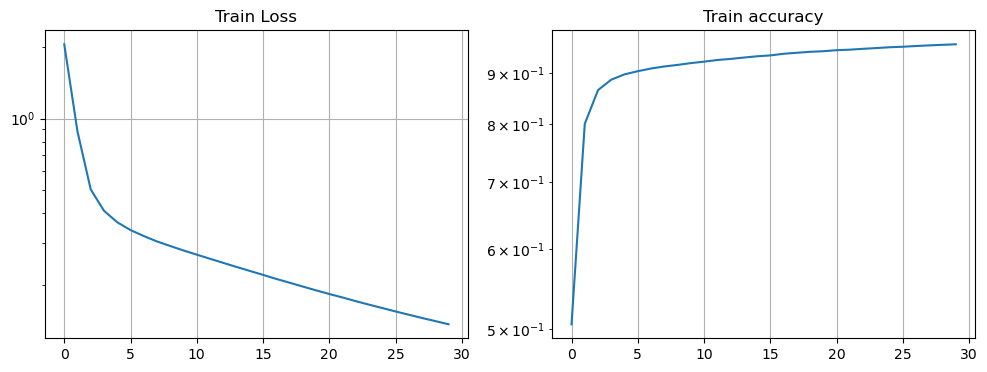

In [66]:
model_train_sgd(model_784_256_128_10_sqd_lr_0001, lr=0.001)

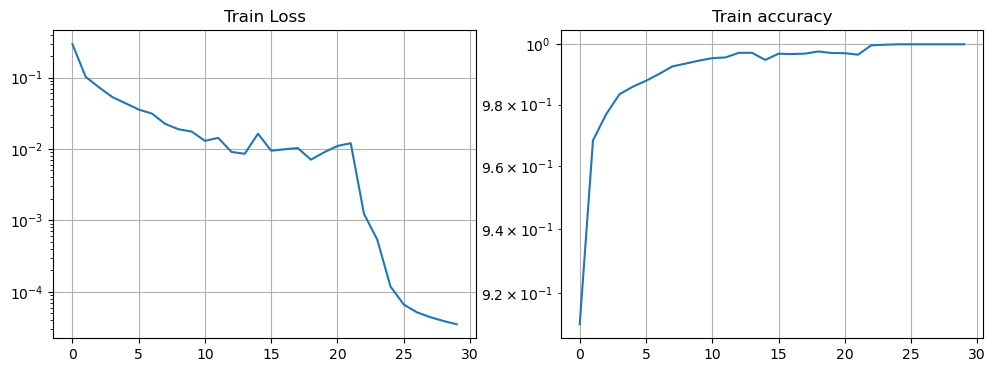

In [67]:
model_train_sgd(model_784_256_128_10_sqd_lr_01, lr=0.1)

In [69]:
# Evaluate the model
model_784_256_128_10_sqd.eval()
results = evaluate_metrics(model_784_256_128_10_sqd)
print("lr 0.01")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_128_10_sqd_lr_0001.eval()
results = evaluate_metrics(model_784_256_128_10_sqd_lr_0001)
print("lr 0.001")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_128_10_sqd_lr_01.eval()
results = evaluate_metrics(model_784_256_128_10_sqd_lr_01)
print("lr 0.1")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

lr 0.01
acuracity: 0.9816
precision: 0.9816016747310858
recall: 0.9814797161701773
f1: 0.9815344199874003

lr 0.001
acuracity: 0.9581
precision: 0.9577712782116498
recall: 0.9576480065433985
f1: 0.9576501457162836

lr 0.1
acuracity: 0.9855
precision: 0.9854716563566888
recall: 0.9853567093975156
f1: 0.9854047421334249


Мы видим что 0.01 и 0.1 получили довольно высокие показатели, но у 0.1 очень страшный график (очень нестабильный), поэтому мы пока что оставим lr=0.1 до лучших времён

**И наконец-то сами архитектуры**

Сначала сделаем однослойные

In [70]:
model_784_256_10 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10)
)

summary(model_784_256_10)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─ReLU: 1-3                              --
├─Linear: 1-4                            2,570
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0

In [71]:
model_784_1024_10 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=1024),
    nn.ReLU(),
    nn.Linear(in_features=1024, out_features=10)
)

summary(model_784_1024_10)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            803,840
├─ReLU: 1-3                              --
├─Linear: 1-4                            10,250
Total params: 814,090
Trainable params: 814,090
Non-trainable params: 0

In [72]:
model_784_64_10 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=10)
)

summary(model_784_64_10)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            50,240
├─ReLU: 1-3                              --
├─Linear: 1-4                            650
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0

Обучим их

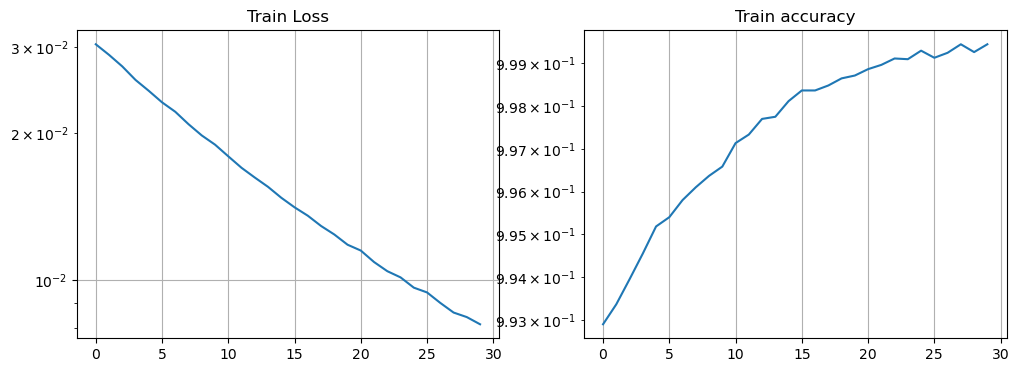

In [74]:
model_train_sgd(model_784_256_10)

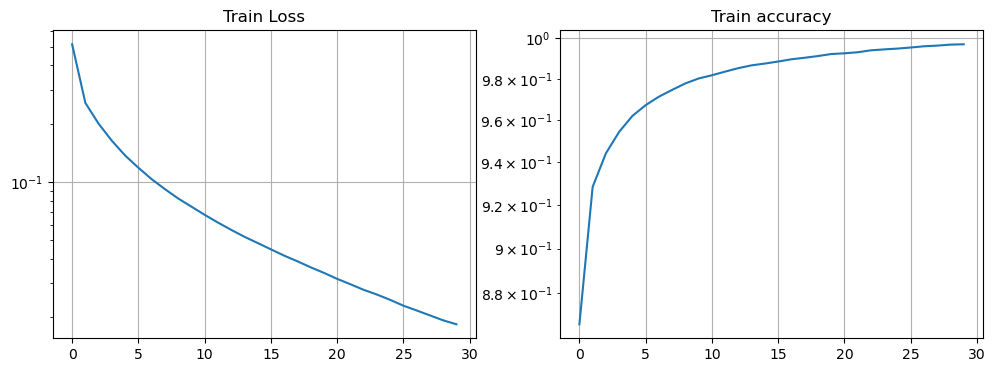

In [75]:
model_train_sgd(model_784_1024_10)

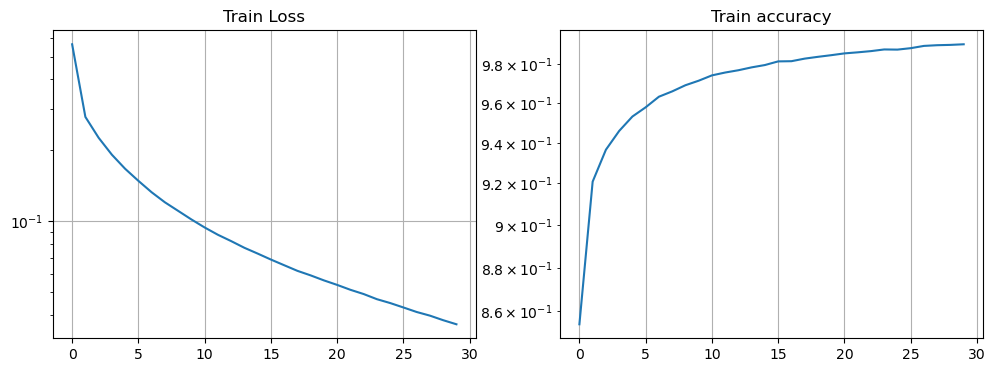

In [76]:
model_train_sgd(model_784_64_10)

In [78]:
# Evaluate the model
model_784_256_10.eval()
results = evaluate_metrics(model_784_256_10)
print("model_784_256_10")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_1024_10.eval()
results = evaluate_metrics(model_784_1024_10)
print("model_784_1024_10")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_64_10.eval()
results = evaluate_metrics(model_784_64_10)
print("model_784_64_10")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

model_784_256_10
acuracity: 0.9806
precision: 0.980605399390663
recall: 0.9803723800122555
f1: 0.980472881930252

model_784_1024_10
acuracity: 0.9821
precision: 0.9820680900238055
recall: 0.9819295401650983
f1: 0.9819866265978445

model_784_64_10
acuracity: 0.9774
precision: 0.9772632538250237
recall: 0.9771695123147885
f1: 0.9772094017741457


модель model_784_1024_10 отработала лучше всех из-за большого количества параметров ~800к, но model_784_256_10 тоже нормально справилась

Дальше проверим 3-ёх слойные (сделаем их на основе лучших предыдущих двух)

In [79]:
model_784_256_256_10 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10)
)

summary(model_784_256_256_10)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─ReLU: 1-3                              --
├─Linear: 1-4                            65,792
├─ReLU: 1-5                              --
├─Linear: 1-6                            2,570
Total params: 269,322
Trainable params: 269,322
Non-trainable params: 0

In [80]:
model_784_1024_256_10 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=1024),
    nn.ReLU(),
    nn.Linear(in_features=1024, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10)
)

summary(model_784_1024_256_10)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            803,840
├─ReLU: 1-3                              --
├─Linear: 1-4                            262,400
├─ReLU: 1-5                              --
├─Linear: 1-6                            2,570
Total params: 1,068,810
Trainable params: 1,068,810
Non-trainable params: 0

In [81]:
model_784_256_1024_10 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=1024),
    nn.ReLU(),
    nn.Linear(in_features=1024, out_features=10)
)

summary(model_784_256_1024_10)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─ReLU: 1-3                              --
├─Linear: 1-4                            263,168
├─ReLU: 1-5                              --
├─Linear: 1-6                            10,250
Total params: 474,378
Trainable params: 474,378
Non-trainable params: 0

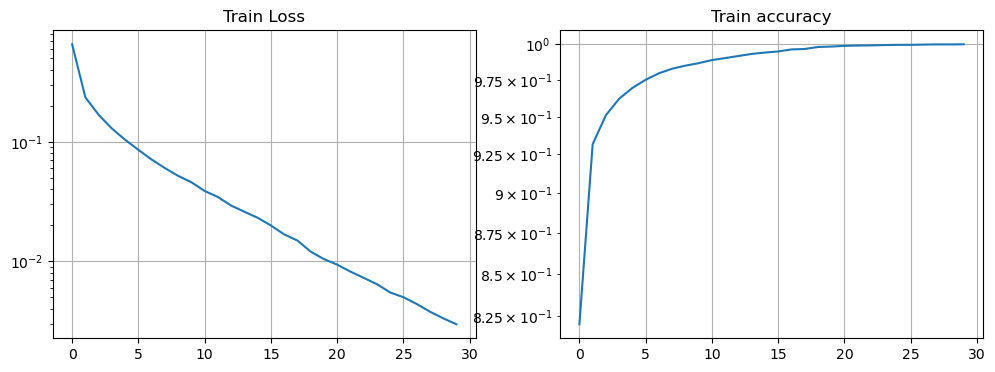

In [82]:
model_train_sgd(model_784_256_256_10)

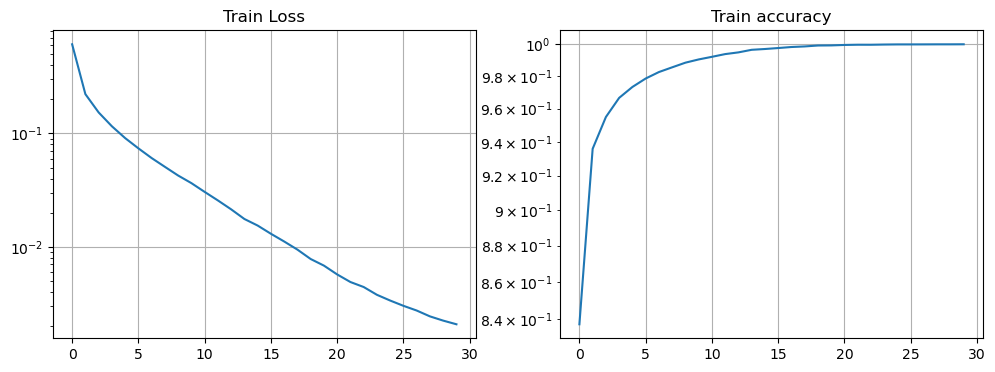

In [83]:
model_train_sgd(model_784_1024_256_10)

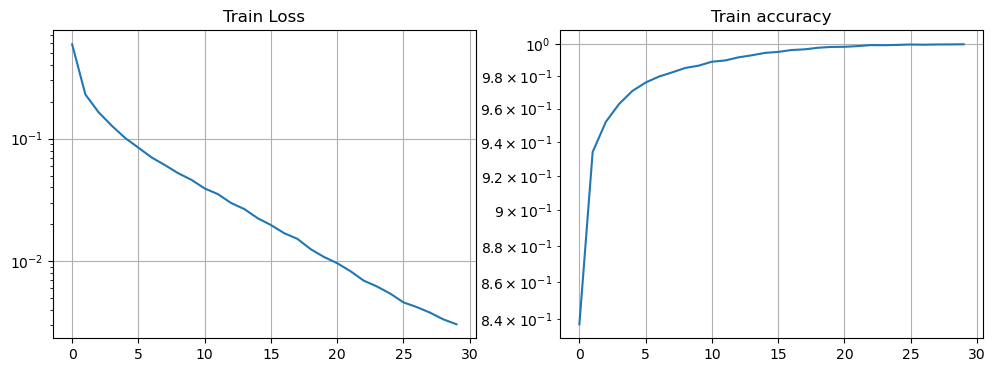

In [84]:
model_train_sgd(model_784_256_1024_10)

In [86]:
# Evaluate the model
model_784_256_256_10.eval()
results = evaluate_metrics(model_784_256_256_10)
print("model_784_256_256_10")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_1024_256_10.eval()
results = evaluate_metrics(model_784_1024_256_10)
print("model_784_1024_256_10")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_1024_10.eval()
results = evaluate_metrics(model_784_256_1024_10)
print("model_784_256_1024_10")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

model_784_256_256_10
acuracity: 0.9814
precision: 0.981498772542356
recall: 0.9811262204839155
f1: 0.9812894068435313

model_784_1024_256_10
acuracity: 0.982
precision: 0.9819581140877247
recall: 0.9818591947613875
f1: 0.9819020715542518

model_784_256_1024_10
acuracity: 0.9805
precision: 0.9804754881850292
recall: 0.9802970004229481
f1: 0.9803639570008059


ожидаемо, самые лучшие показатели получила модель с самым большим количеством параметром model_784_1024_256_10, но если мы вспомним, что model_784_256_128_10_sqd натренировалась на 0.9816 - 3-ое место среди обычных моделек с шагом 0.01, а значит что в модели желательно в следующем слое должно быть меньше features чем в предыдущем, так как model_784_256_1024_10 набрало меньше и если подумать, то становиться понятно: при увеличении признаков сеть синтезировала их неправильно, так как не поняла, как правильно заполнить появившуюся пустоту, так оно и набрало меньше acuracity, хоть и больше в ~2 раза, чем model_784_256_128_10

Так значит, проверять dropout и batchnorm мы будем на архитектурах следующих моделей:
* model_784_1024_256_10 (исключим её так как нам хватит нижних двух)
* model_784_256_128_10_sqd
* model_784_1024_10

Droupout:

In [87]:
model_784_256_128_10_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 10)
)

summary(model_784_256_128_10_dropout)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─ReLU: 1-3                              --
├─Dropout: 1-4                           --
├─Linear: 1-5                            32,896
├─ReLU: 1-6                              --
├─Dropout: 1-7                           --
├─Linear: 1-8                            1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0

In [88]:
model_784_1024_10_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(1024, 10)
)

summary(model_784_1024_10_dropout)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            803,840
├─ReLU: 1-3                              --
├─Dropout: 1-4                           --
├─Linear: 1-5                            10,250
Total params: 814,090
Trainable params: 814,090
Non-trainable params: 0

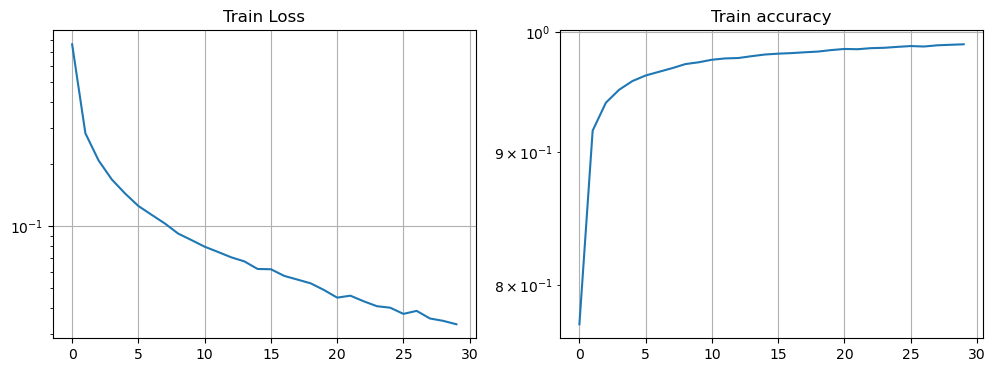

In [89]:
model_train_sgd(model_784_256_128_10_dropout)

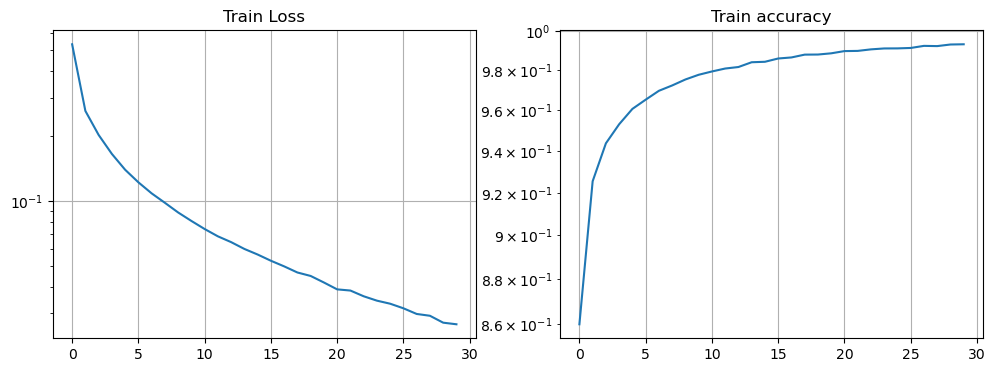

In [90]:
model_train_sgd(model_784_1024_10_dropout)

In [91]:
# Evaluate the model
model_784_256_128_10_dropout.eval()
results = evaluate_metrics(model_784_256_128_10_dropout)
print("model_784_256_128_10_dropout")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_1024_10_dropout.eval()
results = evaluate_metrics(model_784_1024_10_dropout)
print("model_784_1024_10_dropout")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

model_784_256_128_10_dropout
acuracity: 0.9831
precision: 0.9831098494962787
recall: 0.9828997461656259
f1: 0.9829844809482138

model_784_1024_10_dropout
acuracity: 0.9818
precision: 0.9817912970517509
recall: 0.981734402360324
f1: 0.9817506581196511


Неожиданно, droupout позволил двухслойной модели работать лучше и прямо улучшил её, скорее всего, это связано с тем, что droupout позволил ей запоминать общие закономерности, а не зазубривать, как широкой модели, а также у нас стали практически равные precision и recall, что хорошо для предсказывания модели 

Теперь batchnorm

In [92]:
model_784_256_128_10_bn = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

summary(model_784_256_128_10_bn)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─BatchNorm1d: 1-3                       512
├─ReLU: 1-4                              --
├─Linear: 1-5                            32,896
├─BatchNorm1d: 1-6                       256
├─ReLU: 1-7                              --
├─Linear: 1-8                            1,290
Total params: 235,914
Trainable params: 235,914
Non-trainable params: 0

In [93]:
model_784_1024_10_bn = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),

    nn.Linear(1024, 10)
)

summary(model_784_1024_10_bn)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            803,840
├─BatchNorm1d: 1-3                       2,048
├─ReLU: 1-4                              --
├─Linear: 1-5                            10,250
Total params: 816,138
Trainable params: 816,138
Non-trainable params: 0

и настал тот самый момент мы проверим вместе batch norm c шагом 0.1, так как он исправляет обучение с большим шагом

In [100]:
model_784_256_128_10_bn_lr_01 = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

summary(model_784_256_128_10_bn_lr_01)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─BatchNorm1d: 1-3                       512
├─ReLU: 1-4                              --
├─Linear: 1-5                            32,896
├─BatchNorm1d: 1-6                       256
├─ReLU: 1-7                              --
├─Linear: 1-8                            1,290
Total params: 235,914
Trainable params: 235,914
Non-trainable params: 0

In [101]:
model_784_1024_10_bn_lr_01 = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),

    nn.Linear(1024, 10)
)

summary(model_784_1024_10_bn_lr_01)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            803,840
├─BatchNorm1d: 1-3                       2,048
├─ReLU: 1-4                              --
├─Linear: 1-5                            10,250
Total params: 816,138
Trainable params: 816,138
Non-trainable params: 0

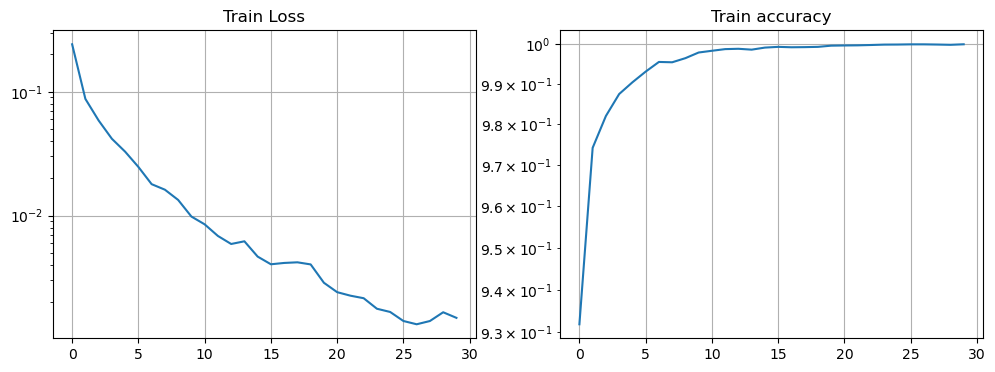

In [96]:
model_train_sgd(model_784_256_128_10_bn)

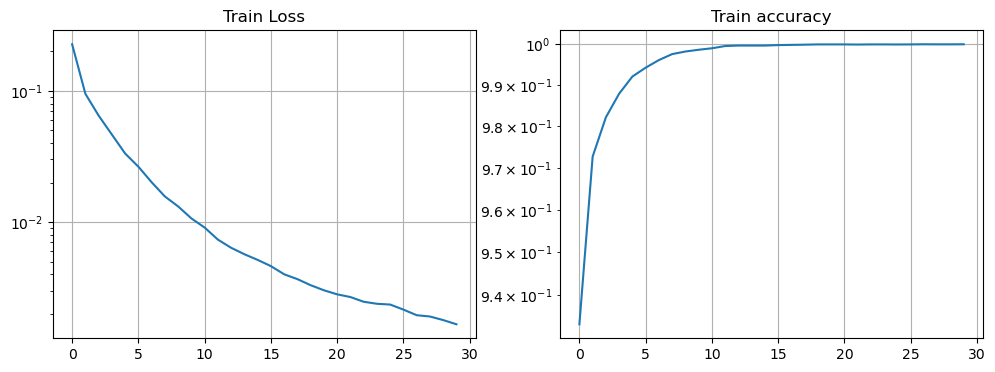

In [97]:
model_train_sgd(model_784_1024_10_bn)

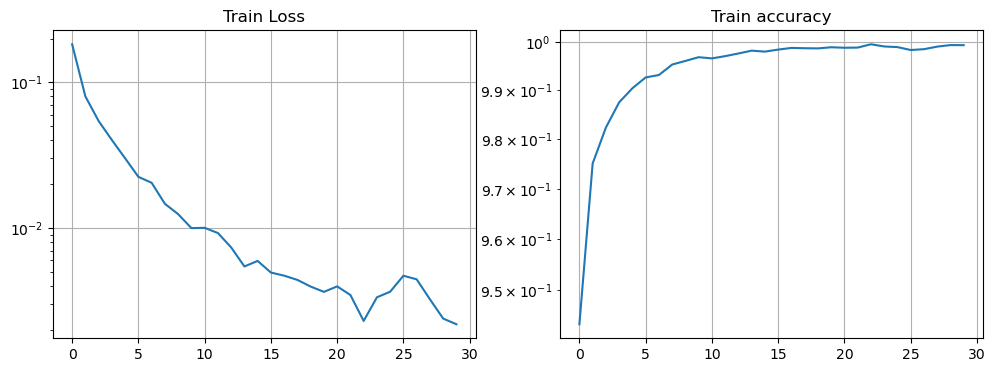

In [102]:
model_train_sgd(model_784_256_128_10_bn_lr_01, lr=0.1)

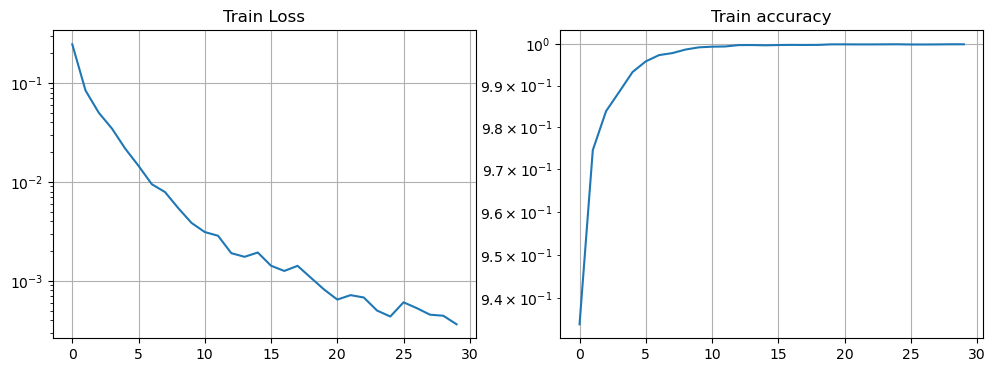

In [103]:
model_train_sgd(model_784_1024_10_bn_lr_01, lr=0.1)

In [130]:
# Evaluate the model
model_784_256_128_10_bn.eval()
results = evaluate_metrics(model_784_256_128_10_bn)
print("model_784_256_128_10_bn")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_1024_10_bn.eval()
results = evaluate_metrics(model_784_1024_10_bn)
print("model_784_1024_10_bn")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_128_10_bn_lr_01.eval()
results = evaluate_metrics(model_784_256_128_10_bn_lr_01)
print("model_784_256_128_10_bn_lr_01")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_1024_10_bn_lr_01.eval()
results = evaluate_metrics(model_784_1024_10_bn_lr_01)
print("model_784_1024_10_bn_lr_01")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")


model_784_256_128_10_bn
acuracity: 0.9826
precision: 0.9825887779683535
recall: 0.9825417963589829
f1: 0.9825596625078653

model_784_1024_10_bn
acuracity: 0.9845
precision: 0.98448925819997
recall: 0.9844277458902833
f1: 0.9844534454985233

model_784_256_128_10_bn_lr_01
acuracity: 0.9846
precision: 0.9845248850243072
recall: 0.9844886697683336
f1: 0.9844995235840981

model_784_1024_10_bn_lr_01
acuracity: 0.9849
precision: 0.9848869085026116
recall: 0.9848431010594556
f1: 0.9848598549952003


Более широкая модель оказалась эффективнее и в общем batchnorm дал ощутимый прирост к аккуратности, также большой шаг показал себя лучше маленького 

Поэтому объединим batchnorm с 0.1 шагом и dropout

In [105]:
model_784_1024_10_bn_dropout = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(1024, 10)
)

summary(model_784_1024_10_bn_dropout)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            803,840
├─BatchNorm1d: 1-3                       2,048
├─ReLU: 1-4                              --
├─Dropout: 1-5                           --
├─Linear: 1-6                            10,250
Total params: 816,138
Trainable params: 816,138
Non-trainable params: 0

In [106]:
model_784_256_128_10_bn_dropout = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 10)
)

summary(model_784_256_128_10_bn_dropout)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─BatchNorm1d: 1-3                       512
├─ReLU: 1-4                              --
├─Dropout: 1-5                           --
├─Linear: 1-6                            32,896
├─BatchNorm1d: 1-7                       256
├─ReLU: 1-8                              --
├─Dropout: 1-9                           --
├─Linear: 1-10                           1,290
Total params: 235,914
Trainable params: 235,914
Non-trainable params: 0

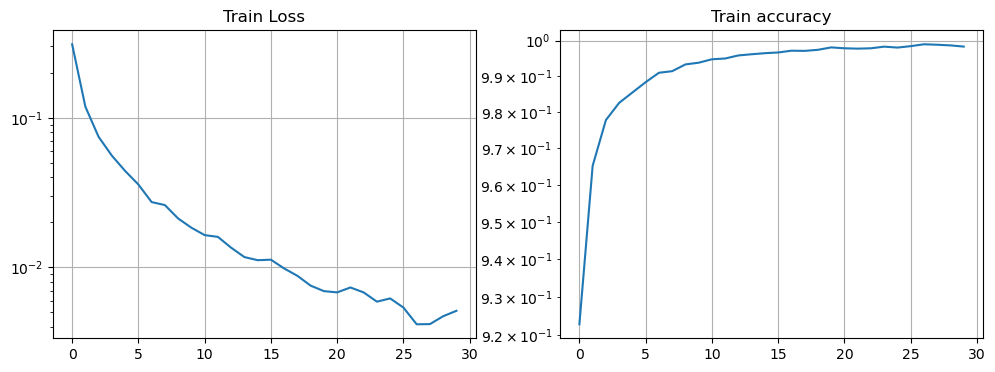

In [107]:
model_train_sgd(model_784_1024_10_bn_dropout, lr=0.1)

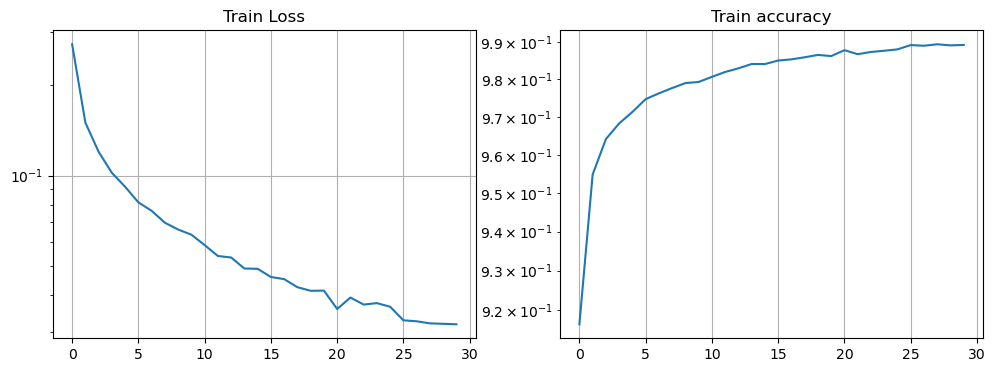

In [108]:
model_train_sgd(model_784_256_128_10_bn_dropout, lr=0.1)

In [109]:
# Evaluate the model
model_784_1024_10_bn_dropout.eval()
results = evaluate_metrics(model_784_1024_10_bn_dropout)
print("model_784_1024_10_bn_dropout")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_128_10_bn_dropout.eval()
results = evaluate_metrics(model_784_256_128_10_bn_dropout)
print("model_784_256_128_10_bn_dropout")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

model_784_1024_10_bn_dropout
acuracity: 0.9852
precision: 0.9851452666380898
recall: 0.9850736598543239
f1: 0.9850961703312411

model_784_256_128_10_bn_dropout
acuracity: 0.9857
precision: 0.9856850250790723
recall: 0.9855345971582098
f1: 0.9855970546981506


Модели получили хороший прирост, сочетание двух техник принесло свои плоды

И последнее что мы проверим это другие функции активации gelu и leakyrelu, соединим их вместе с batchnorn+dropout

In [116]:
model_784_256_128_10_leaky = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.LeakyReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.LeakyReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 10)
)

summary(model_784_256_128_10_leaky)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─BatchNorm1d: 1-3                       512
├─LeakyReLU: 1-4                         --
├─Dropout: 1-5                           --
├─Linear: 1-6                            32,896
├─BatchNorm1d: 1-7                       256
├─LeakyReLU: 1-8                         --
├─Dropout: 1-9                           --
├─Linear: 1-10                           1,290
Total params: 235,914
Trainable params: 235,914
Non-trainable params: 0

In [117]:
model_784_256_128_10_gelu = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.GELU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.GELU(),
    nn.Dropout(0.3),

    nn.Linear(128, 10)
)

summary(model_784_256_128_10_gelu)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─BatchNorm1d: 1-3                       512
├─GELU: 1-4                              --
├─Dropout: 1-5                           --
├─Linear: 1-6                            32,896
├─BatchNorm1d: 1-7                       256
├─GELU: 1-8                              --
├─Dropout: 1-9                           --
├─Linear: 1-10                           1,290
Total params: 235,914
Trainable params: 235,914
Non-trainable params: 0

In [118]:
model_784_1024_10_leaky = nn.Sequential(
     nn.Flatten(),

    nn.Linear(784, 1024),
    nn.BatchNorm1d(1024),
    nn.LeakyReLU(),
    nn.Dropout(0.3),

    nn.Linear(1024, 10)
)

summary(model_784_1024_10_leaky)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            803,840
├─BatchNorm1d: 1-3                       2,048
├─LeakyReLU: 1-4                         --
├─Dropout: 1-5                           --
├─Linear: 1-6                            10,250
Total params: 816,138
Trainable params: 816,138
Non-trainable params: 0

In [119]:
model_784_1024_10_gelu = nn.Sequential(
     nn.Flatten(),

    nn.Linear(784, 1024),
    nn.BatchNorm1d(1024),
    nn.GELU(),
    nn.Dropout(0.3),

    nn.Linear(1024, 10)
)

summary(model_784_1024_10_gelu)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            803,840
├─BatchNorm1d: 1-3                       2,048
├─GELU: 1-4                              --
├─Dropout: 1-5                           --
├─Linear: 1-6                            10,250
Total params: 816,138
Trainable params: 816,138
Non-trainable params: 0

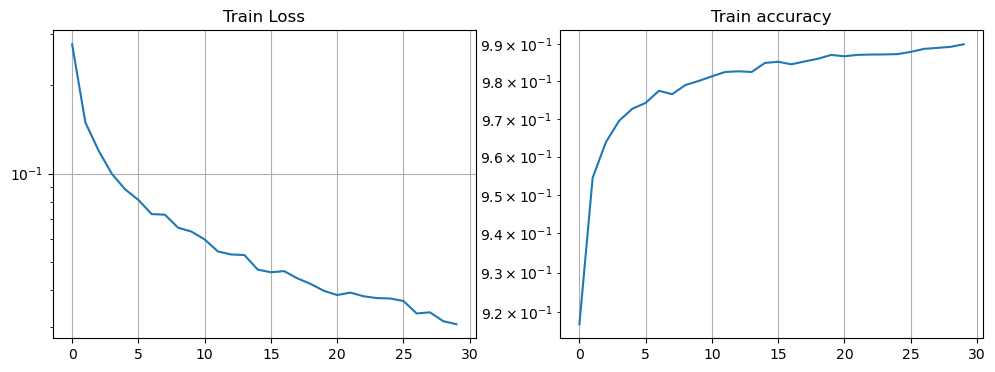

In [123]:
model_train_sgd(model_784_256_128_10_leaky, lr=0.1)

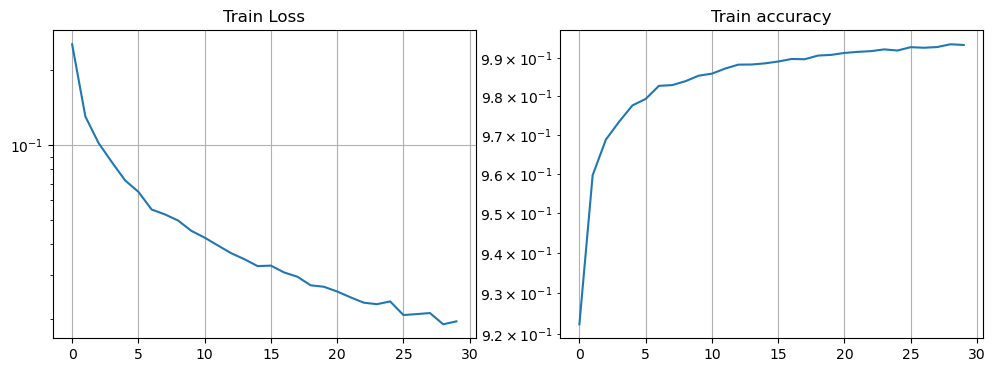

In [ ]:
model_train_sgd(model_784_256_128_10_gelu, lr=0.1)

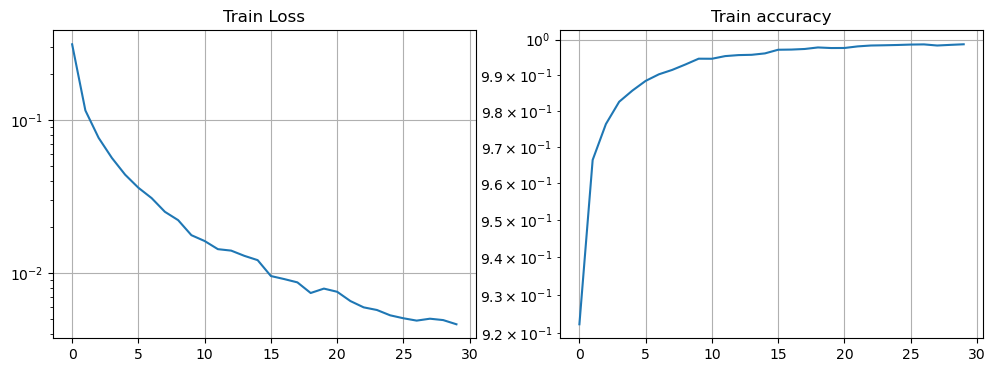

In [121]:
model_train_sgd(model_784_1024_10_leaky, lr=0.1)

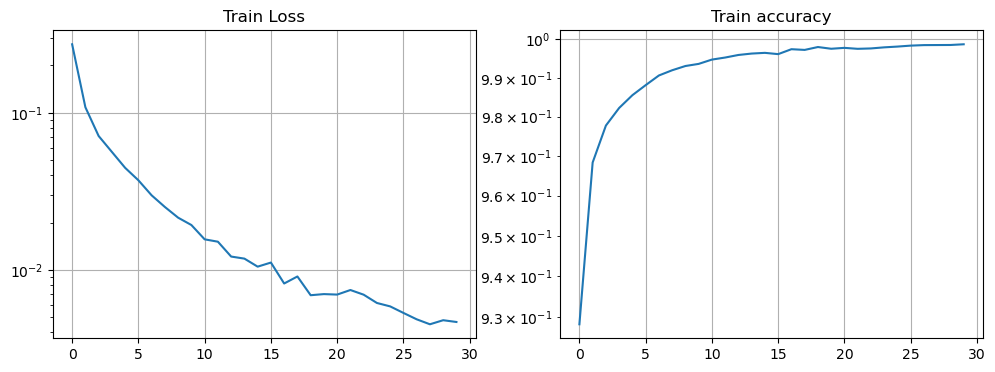

In [120]:
model_train_sgd(model_784_1024_10_gelu, lr=0.1)

In [132]:
# Evaluate the model
model_784_256_128_10_leaky.eval()
results = evaluate_metrics(model_784_256_128_10_leaky)
print("model_784_256_128_10_leaky")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_256_128_10_gelu.eval()
results = evaluate_metrics(model_784_256_128_10_gelu)
print("model_784_256_128_10_gelu")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_1024_10_leaky.eval()
results = evaluate_metrics(model_784_1024_10_leaky)
print("model_784_1024_10_leaky")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

print()

model_784_1024_10_gelu.eval()
results = evaluate_metrics(model_784_1024_10_gelu)
print("model_784_1024_10_gelu")
print(f"acuracity: {float(results[0])}")
print(f"precision: {float(results[1])}")
print(f"recall: {float(results[2])}")
print(f"f1: {float(results[3])}")

model_784_256_128_10_leaky
acuracity: 0.9848
precision: 0.9847858046281386
recall: 0.9847300191266252
f1: 0.9847468896075711

model_784_256_128_10_gelu
acuracity: 0.9844
precision: 0.9844480450338473
recall: 0.9842572091190709
f1: 0.9843427456348713

model_784_1024_10_leaky
acuracity: 0.9846
precision: 0.9844818174234977
recall: 0.9845316241647746
f1: 0.9844886791550607

model_784_1024_10_gelu
acuracity: 0.9838
precision: 0.9837166958791282
recall: 0.9838005864647392
f1: 0.9837515984792689


Мы видим что relu лучшая функция под batch norm с lr=0.1 и droupout

В итоге мы обучили:

1. model_784_256_128_10_adam
2. model_784_256_128_10_sqd

3. model_784_256_128_10_sqd_20_epoch
4. model_784_256_128_10_sqd_10_epoch

5. model_784_256_128_10_sqd_lr_0001
6. model_784_256_128_10_sqd_lr_01

7. model_784_256_10
8. model_784_1024_10
9. model_784_64_10

10. model_784_256_256_10
11. model_784_1024_256_10
12. model_784_256_1024_10

13. model_784_256_128_10_dropout
14. model_784_1024_10_dropout

15. model_784_256_128_10_bn
16. model_784_1024_10_bn

17. model_784_1024_10_bn_lr_01
18. model_784_256_128_10_bn_lr_01

19. model_784_256_128_10_dropout_bn
20. model_784_1024_10_dropout_bn

21. model_784_1024_10_bn_lr_01_gelu
22. model_784_1024_10_bn_lr_01_leaky

23. model_784_1024_10_gelu
24. model_784_1024_10_leaky


Сделаем финальную табличку

In [133]:
import pandas as pd

models_dict = {
    # Группа 1: Сравнение ширины (3)
    "Single_Slim_64": model_784_64_10,
    "Single_Base_256": model_784_256_10,
    "Single_Wide_1024": model_784_1024_10,
    
    # Группа 2: Архитектурные вариации (Depth/Width) (4)
    "Triple_Base_256_128": model_784_256_128_10_sqd,
    "Deep_256_256": model_784_256_256_10,
    "Deep_1024_256": model_784_1024_256_10,
    "Deep_256_1024": model_784_256_1024_10,
    
    # Группа 3: Оптимизация и Регуляризация (Base 256-128) (7)
    "Triple_Adam": model_784_256_128_10_adam,
    "Triple_Dropout": model_784_256_128_10_dropout,
    "Triple_BN": model_784_256_128_10_bn,
    "Triple_BN_LR01": model_784_256_128_10_bn_lr_01,
    "Triple_Dropout_BN": model_784_256_128_10_bn_dropout,
    "Triple_GELU": model_784_256_128_10_gelu,
    "Triple_Leaky": model_784_256_128_10_leaky,
    
    # Группа 4: Оптимизация и Регуляризация (Base 1024) (6)
    "Wide_Dropout": model_784_1024_10_dropout,
    "Wide_BN": model_784_1024_10_bn,
    "Wide_BN_LR01": model_784_1024_10_bn_lr_01,
    "Wide_Dropout_BN": model_784_1024_10_bn_dropout,
    "Wide_GELU": model_784_1024_10_gelu,
    "Wide_Leaky": model_784_1024_10_leaky,
    
    # Группа 5: Вариации обучения (Epochs/LR) (4)
    "Triple_SQD_LR0001": model_784_256_128_10_sqd_lr_0001,
    "Triple_SQD_LR01": model_784_256_128_10_sqd_lr_01,
    "Triple_SQD_10_Epoch": model_784_256_128_10_sqd_10_epoch,
    "Triple_SQD_20_Epoch": model_784_256_128_10_sqd_20_epoch
}

results = []

for name, model in models_dict.items():
    acc, p, r, f1 = evaluate_metrics(model)
    results.append({
        "Experiment": name,
        "Accuracy": acc,
        "Precision": p,
        "Recall": r,
        "F1": f1
    })

df = pd.DataFrame(results)

print(df)

             Experiment  Accuracy  Precision    Recall        F1
0        Single_Slim_64    0.9774   0.977263  0.977170  0.977209
1       Single_Base_256    0.9806   0.980605  0.980372  0.980473
2      Single_Wide_1024    0.9821   0.982068  0.981930  0.981987
3   Triple_Base_256_128    0.9816   0.981602  0.981480  0.981534
4          Deep_256_256    0.9814   0.981499  0.981126  0.981289
5         Deep_1024_256    0.9820   0.981958  0.981859  0.981902
6         Deep_256_1024    0.9805   0.980475  0.980297  0.980364
7           Triple_Adam    0.9742   0.974097  0.973995  0.973960
8        Triple_Dropout    0.9831   0.983110  0.982900  0.982984
9             Triple_BN    0.9826   0.982589  0.982542  0.982560
10       Triple_BN_LR01    0.9846   0.984525  0.984489  0.984500
11    Triple_Dropout_BN    0.9857   0.985685  0.985535  0.985597
12          Triple_GELU    0.9844   0.984448  0.984257  0.984343
13         Triple_Leaky    0.9848   0.984786  0.984730  0.984747
14         Wide_Dropout  

In [134]:
df_sorted = df.sort_values(by='Accuracy', ascending=False)

df_sorted

,Experiment,Accuracy,Precision,Recall,F1
11,Triple_Dropout_BN,0.9857,0.985685,0.985535,0.985597
21,Triple_SQD_LR01,0.9855,0.985472,0.985357,0.985405
17,Wide_Dropout_BN,0.9852,0.985145,0.985074,0.985096
16,Wide_BN_LR01,0.9849,0.984887,0.984843,0.984860
13,Triple_Leaky,0.9848,0.984786,0.984730,0.984747
19,Wide_Leaky,0.9846,0.984482,0.984532,0.984489
10,Triple_BN_LR01,0.9846,0.984525,0.984489,0.984500
15,Wide_BN,0.9845,0.984489,0.984428,0.984453
12,Triple_GELU,0.9844,0.984448,0.984257,0.984343
18,Wide_GELU,0.9838,0.983717,0.983801,0.983752


***Наилучший результат (0.9857) показала трехслойная архитектура, объединившая в себе Batch Normalization (BN) с lr = 0.1 и Dropout.***

**Почему Triple_Dropout_BN-модель смогла победить?**

1. BN стабилизирует распределение данных между слоями, позволяя сети обучаться быстрее, а Dropout предотвращает переобучение. Вместе они хорошо увеличивают аккуратность модели, даже широкая модель (Wide_Dropout_BN) смогла, благодаря этим двум методам, набрать хороший accuracy	

2. Трехслойная структура (Triple) оказалась эффективнее однослойной (Wide), так как лишний слой позволил модели стоить более сложные закономерности, что предотвратило переобучение

**Влияние параметров обучения:**

* Модель с LR 0.1 (№21) показала себя значительно лучше, чем с LR 0.0001 (№20). Мы видим, что больший шаг нашёл более удачный локальный минимум, когда модель с LR 0.001 оказалась в плохом локальном минимуме или не успела дойти до оптимума, а также при использовании BN с LR 0.1 сеть не боится больших шагов и быстрее находит глобальный минимум (№11, №17, №16, №10).

* Функции активации Leaky ReLU и GELU (№13, №12, №18, №19) с Droupout и BN с LR 0.1 оказались хуже, чем обычная ReLU с такими же помощниками, что говорит о том, что мы скорее всего не расскрыли потенциал этих функций и они будут лучше с другой архитектурой и помощниками

**А что там по худшим?**

Модель с очень низким шагом обучения (№20), базовая маленькая сеть (№0) и модель с маленьким количеством эпох (№22)  закономерно оказались в хвосте. В первом случае сети просто не хватило времени дойти до оптимума, как и у модели с маленьким количеством эпох, а во втором — не хватило параметров для описания всех сложностей данных.

Что более удивительно Adam сработал хуже Sqd, Скорее всего, его результат 0.9742 — либо был слишком высокий Learning Rate или оказалось так, что он слишком быстро сошелся


Довольно интересное задание